In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Create the dataset
data = {
    'Month': pd.date_range(start='2022-01-01', periods=12, freq='MS'),

    'Television': [145, 145, 105, 171, 178, 167, 200, 181, 152, 143, 114, 109],

    'Mobile Phones': [335, 362, 311, 259, 277, 292, 385, 388, 291, 345, 399, 250],

    'Laptop': [82, 126, 95, 93, 107, 145, 77, 78, 83, 102, 99, 101]
}

df = pd.DataFrame(data)

# Add total column
df['Total'] = df[['Television', 'Mobile Phones', 'Laptop']].sum(axis=1)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (12, 5)


,Month,Television,Mobile Phones,Laptop,Total
0,2022-01-01,145,335,82,562
1,2022-02-01,145,362,126,633
2,2022-03-01,105,311,95,511
3,2022-04-01,171,259,93,523
4,2022-05-01,178,277,107,562


In [2]:
# Display nicely
df_display = df.copy()

df_display['Month'] = df_display['Month'].dt.strftime('%b %Y')

print(df_display)

       Month  Television  Mobile Phones  Laptop  Total
0   Jan 2022         145            335      82    562
1   Feb 2022         145            362     126    633
2   Mar 2022         105            311      95    511
3   Apr 2022         171            259      93    523
4   May 2022         178            277     107    562
5   Jun 2022         167            292     145    604
6   Jul 2022         200            385      77    662
7   Aug 2022         181            388      78    647
8   Sep 2022         152            291      83    526
9   Oct 2022         143            345     102    590
10  Nov 2022         114            399      99    612
11  Dec 2022         109            250     101    460


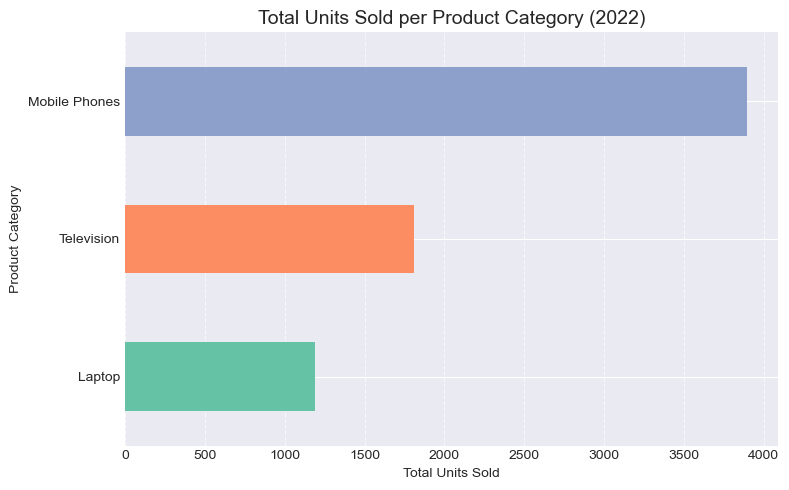

In [3]:
# Bar chart: total sales per product category

totals = df[['Television', 'Mobile Phones', 'Laptop']].sum()

plt.figure(figsize=(8,5))

totals.sort_values().plot(
    kind='barh',
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)

plt.title('Total Units Sold per Product Category (2022)', fontsize=14)

plt.xlabel('Total Units Sold')

plt.ylabel('Product Category')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

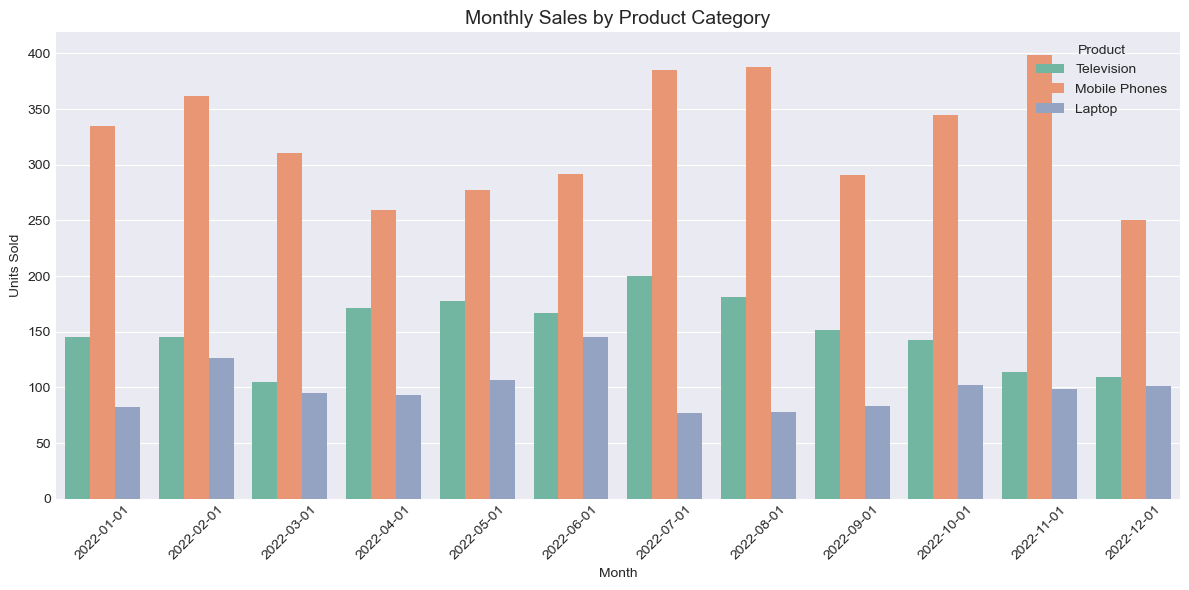

In [4]:
# Column chart: monthly sales per product

df_monthly = df.melt(
    id_vars='Month',
    value_vars=['Television', 'Mobile Phones', 'Laptop'],
    var_name='Product',
    value_name='Units Sold'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_monthly,
    x='Month',
    y='Units Sold',
    hue='Product'
)

plt.title('Monthly Sales by Product Category', fontsize=14)

plt.xlabel('Month')

plt.ylabel('Units Sold')

plt.xticks(rotation=45)

plt.legend(title='Product')

plt.tight_layout()

plt.show()

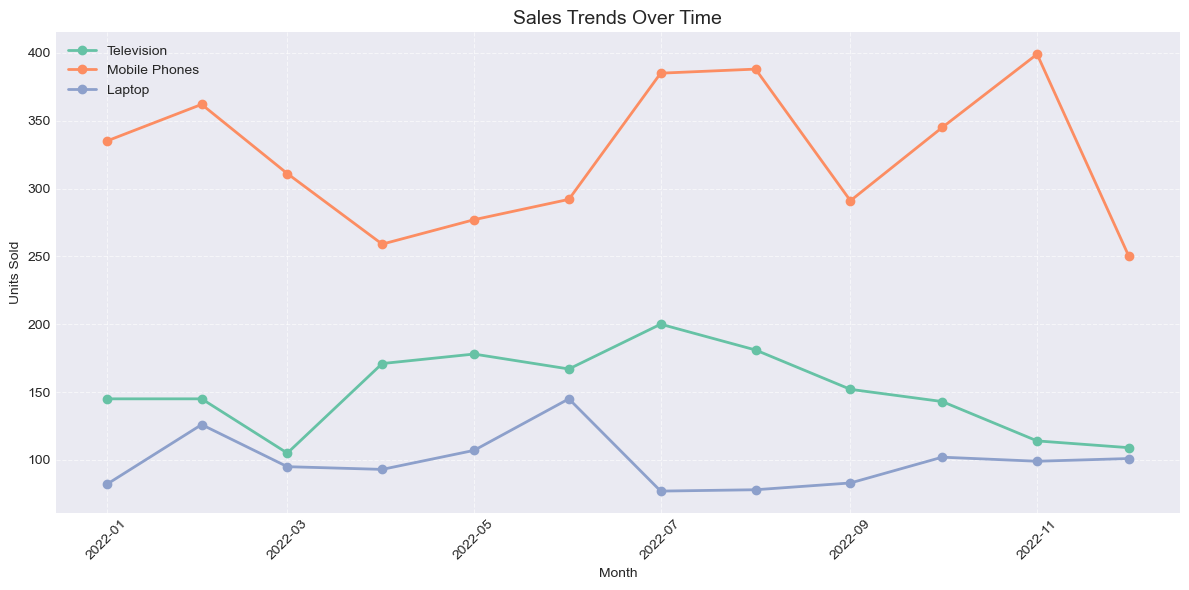

In [5]:
# Line chart: sales trends over time

plt.figure(figsize=(12,6))

for product in ['Television', 'Mobile Phones', 'Laptop']:

    plt.plot(
        df['Month'],
        df[product],
        marker='o',
        linewidth=2,
        label=product
    )

plt.title('Sales Trends Over Time', fontsize=14)

plt.xlabel('Month')

plt.ylabel('Units Sold')

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

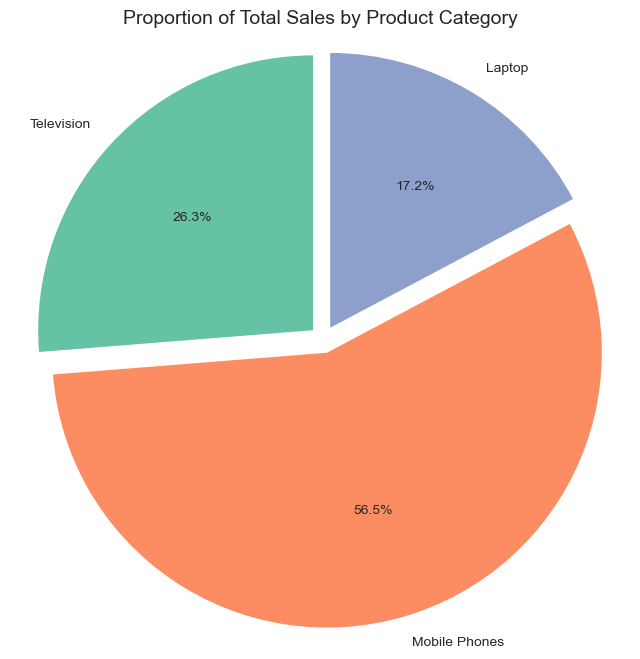

In [6]:
# Pie chart

totals = df[['Television', 'Mobile Phones', 'Laptop']].sum()

plt.figure(figsize=(8,8))

plt.pie(
    totals,
    labels=totals.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62', '#8da0cb'],
    explode=(0.05, 0.05, 0.05)
)

plt.title('Proportion of Total Sales by Product Category', fontsize=14)

plt.axis('equal')

plt.show()

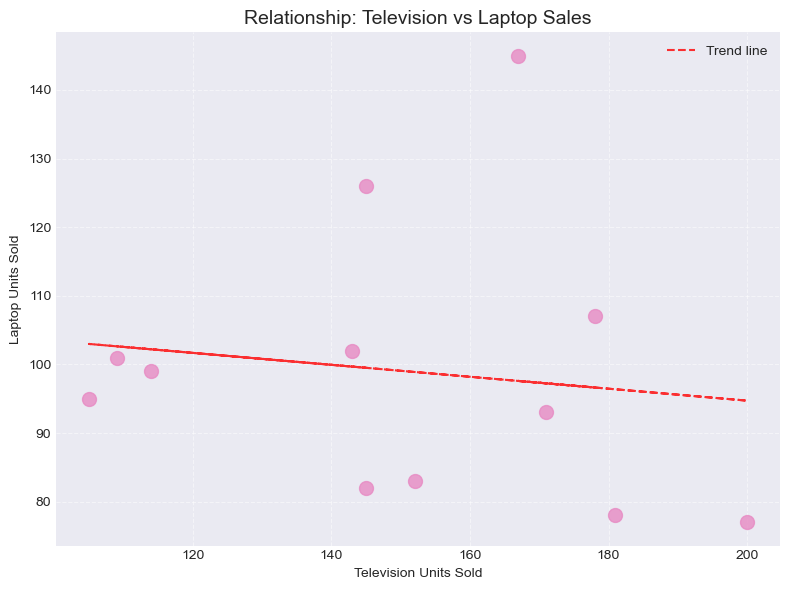

In [7]:
# Scatter plot

plt.figure(figsize=(8,6))

plt.scatter(
    df['Television'],
    df['Laptop'],
    color='#e78ac3',
    s=100,
    alpha=0.8
)

plt.title('Relationship: Television vs Laptop Sales', fontsize=14)

plt.xlabel('Television Units Sold')

plt.ylabel('Laptop Units Sold')

plt.grid(True, linestyle='--', alpha=0.5)

# Add trend line
z = np.polyfit(df['Television'], df['Laptop'], 1)

p = np.poly1d(z)

plt.plot(
    df['Television'],
    p(df['Television']),
    "r--",
    alpha=0.8,
    label='Trend line'
)

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
# Waterfall chart using custom function

def waterfall_chart(data, title="Waterfall Chart"):

    # Create dataframe
    df_waterfall = pd.DataFrame({'Change': data})

    df_waterfall['Cumulative'] = df_waterfall['Change'].cumsum()

    df_waterfall['Start'] = df_waterfall['Cumulative'].shift(1).fillna(0)

    df_waterfall['End'] = df_waterfall['Cumulative']

    df_waterfall['Up'] = df_waterfall['Change'] > 0

    colors = [
        '#66c2a5' if up else '#fc8d62'
        for up in df_waterfall['Up']
    ]

    plt.figure(figsize=(12,5))

    plt.bar(
        range(len(data)),
        df_waterfall['Change'],
        color=colors,
        edgecolor='black'
    )

    plt.axhline(0, color='black', linewidth=0.8)

    plt.xticks(
        range(len(data)),
        [f'Month {i+1}' for i in range(len(data))]
    )

    plt.title(title, fontsize=14)

    plt.ylabel('Change in Total Sales')

    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for i, (start, change) in enumerate(
        zip(df_waterfall['Start'], df_waterfall['Change'])
    ):

        plt.text(
            i,
            start + change/2,
            f'{change}',
            ha='center',
            va='center'
        )

    plt.tight_layout()

    plt.show()

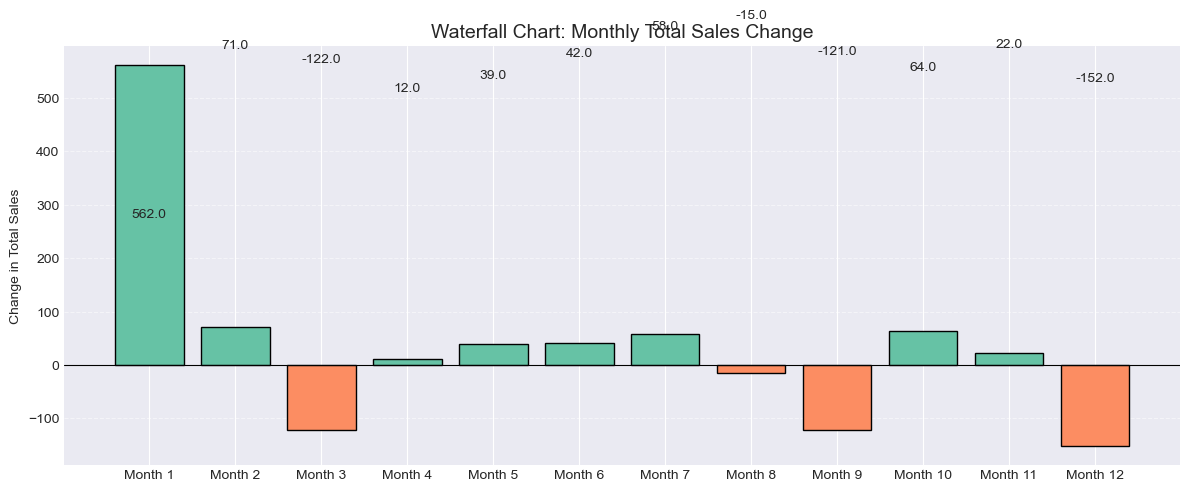

In [9]:
# Monthly total sales changes

monthly_changes = df['Total'].diff().fillna(df['Total'].iloc[0]).tolist()

waterfall_chart(
    monthly_changes,
    title="Waterfall Chart: Monthly Total Sales Change"
)

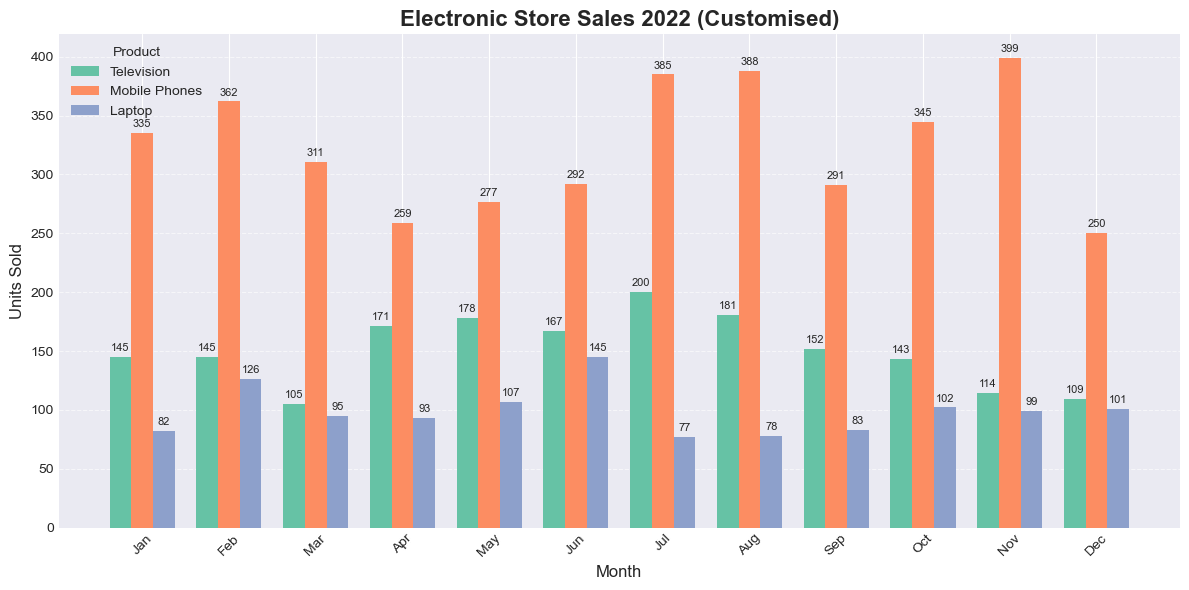

In [10]:
# Recreate a column chart with full customisation

fig, ax = plt.subplots(figsize=(12,6))

width = 0.25

x = np.arange(len(df))

ax.bar(
    x - width,
    df['Television'],
    width,
    label='Television',
    color='#66c2a5'
)

ax.bar(
    x,
    df['Mobile Phones'],
    width,
    label='Mobile Phones',
    color='#fc8d62'
)

ax.bar(
    x + width,
    df['Laptop'],
    width,
    label='Laptop',
    color='#8da0cb'
)

# Customisations
ax.set_title(
    'Electronic Store Sales 2022 (Customised)',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Month', fontsize=12)

ax.set_ylabel('Units Sold', fontsize=12)

ax.set_xticks(x)

ax.set_xticklabels(
    df['Month'].dt.strftime('%b'),
    rotation=45
)

ax.legend(loc='upper left', title='Product')

ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.set_axisbelow(True)

# Add data labels
for i, (tv, mp, lap) in enumerate(
    zip(
        df['Television'],
        df['Mobile Phones'],
        df['Laptop']
    )
):

    ax.text(i - width, tv + 5, str(tv), ha='center', fontsize=8)

    ax.text(i, mp + 5, str(mp), ha='center', fontsize=8)

    ax.text(i + width, lap + 5, str(lap), ha='center', fontsize=8)

plt.tight_layout()

plt.show()

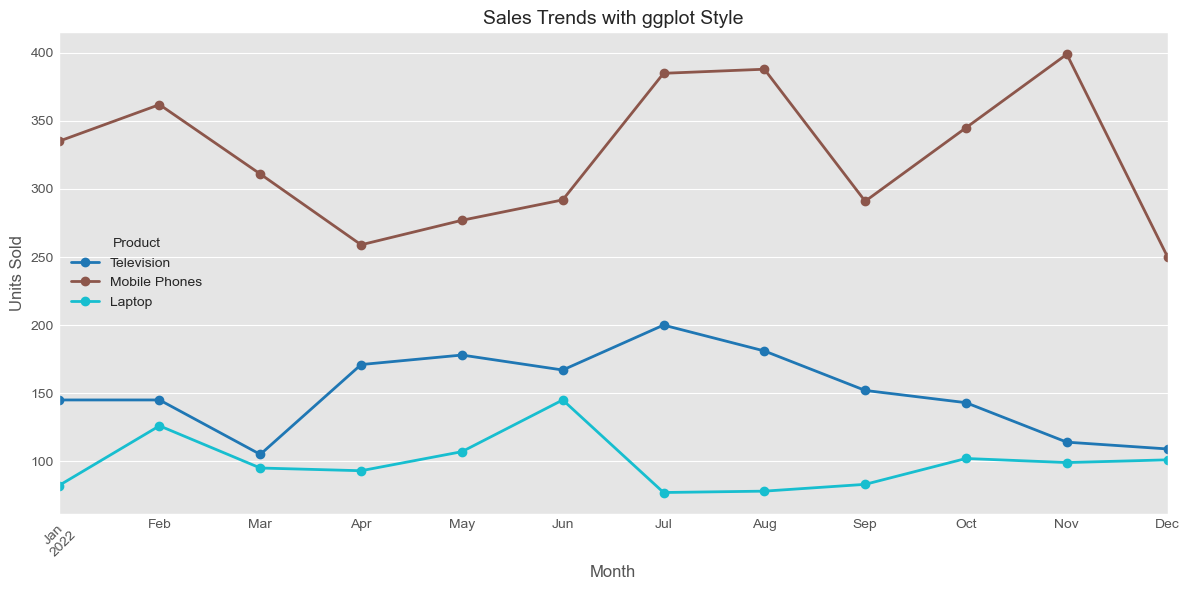

In [11]:
# Apply a different style and color palette

plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(12,6))

df.plot(
    x='Month',
    y=['Television', 'Mobile Phones', 'Laptop'],
    kind='line',
    marker='o',
    ax=ax,
    colormap='tab10',
    linewidth=2
)

ax.set_title('Sales Trends with ggplot Style', fontsize=14)

ax.set_xlabel('Month')

ax.set_ylabel('Units Sold')

ax.legend(title='Product')

ax.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Reset style
plt.style.use('seaborn-v0_8-darkgrid')